In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit

### This script will run a Random Forest Regression and an XGBoost model

In [15]:
# Load the data

data = pd.read_csv('acs_conflict_combined_cleaned.csv')

In [16]:
# Define features and label

X = data.drop(['event_count', 'ZCTA', 'Month'], axis=1)
Y = data['event_count']

In [17]:
# Time Series Cross Validation

tscv = TimeSeriesSplit(n_splits=5)

In [18]:
# Split the dataset into training and test sets

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=1)

In [19]:
# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
# Apply and train the Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=100)
rf_regressor.fit(X_train, Y_train)

RandomForestRegressor(random_state=100)

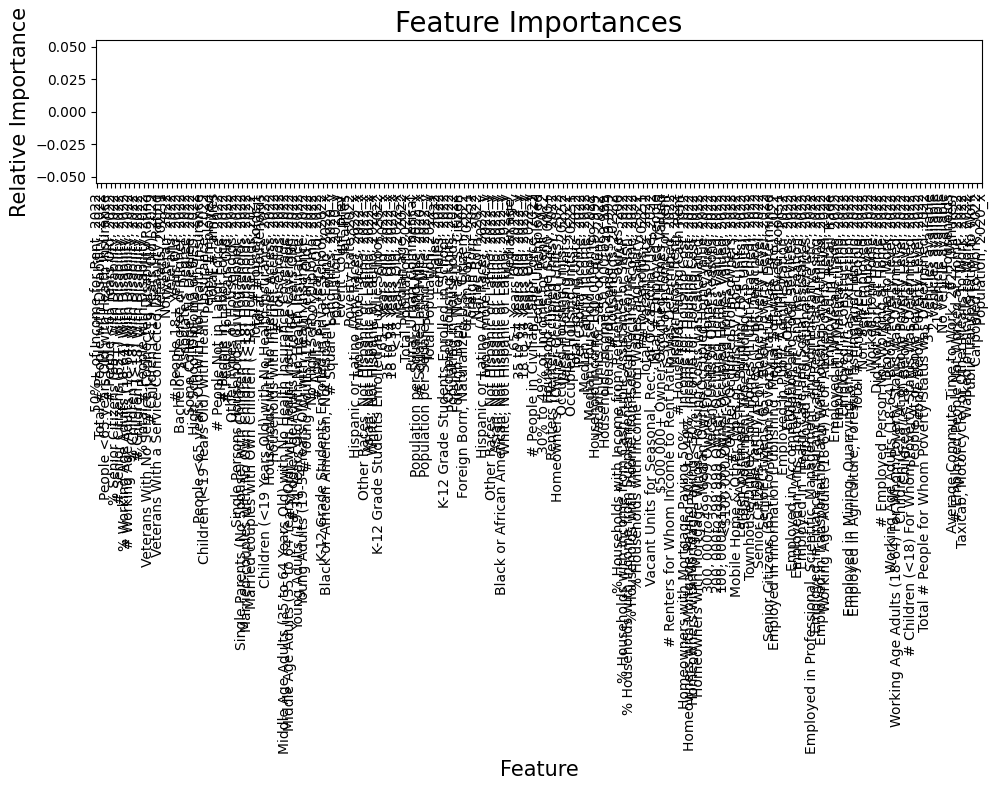

In [21]:
feature_importances = rf_regressor.feature_importances_
feature_names = X.columns

# Sort the feature importances in descending order and get their indices
sorted_indices = np.argsort(feature_importances)[::-1]

# Create the plot
plt.figure(figsize=(10, 8))
plt.title('Feature Importances', fontsize=20)
plt.bar(range(len(feature_importances)), feature_importances[sorted_indices], align='center', alpha=0.5)
plt.xticks(range(len(feature_importances)), feature_names[sorted_indices], rotation=90)
plt.ylabel('Relative Importance', fontsize=15)
plt.xlabel('Feature', fontsize=15)
plt.tight_layout()  # Adjusts the plot to ensure everything fits without overlapping
plt.show()

In [22]:
Y_pred = rf_regressor.predict(X_test)

predictions = pd.DataFrame({'Actual': Y_test, 'Predicted': Y_pred})
print(Y_pred)

[0.006203   0.00655349 0.00702031 ... 0.4309429  0.00629923 0.006203  ]


In [23]:
mse = mean_squared_error(Y_test, Y_pred)

print('Mean Squared Error:', mse)

Mean Squared Error: 0.07387649930433778


In [ ]:
# XGBoost Model

